# Advertising Benchmark

This notebook imports saved advertising runs from `results/advertising`. It is analysis-only and does not run training.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))

from mfc.visualization import (
    best_runs_by_label,
    discrete_transport_tv_bound_table,
    load_runs,
    objective_table,
    plot_advertising_diagnostics,
    plot_state_flow,
    plot_validation_rewards,
    runtime_table,
)

ENV = 'advertising'
RESULTS_ROOT = ROOT / 'results'
runs = load_runs(RESULTS_ROOT, env=ENV)
print(f'Loaded {len(runs)} saved runs from {RESULTS_ROOT / ENV}')

Loaded 30 saved runs from /home/adonis/Internship/mfc/results/advertising


## Validation Reward

Mean validation reward over training, with one standard deviation across seeds. The reward balances customer acquisition against advertising cost.

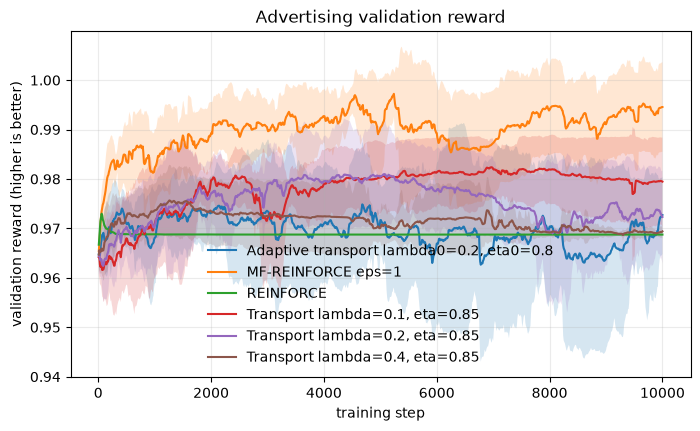

In [2]:
if not runs:
    print('No saved runs yet. Run scripts/run.py before executing the analysis cells.')
else:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    plot_validation_rewards(runs, env=ENV, horizon=5, flow='exact', ax=ax)
    ax.set_title('Advertising validation reward')
    plt.show()

## Customer Share and Ad Intensity

For each selected learned policy, this plot shows the customer share and the average probability of displaying an ad over the validation horizon.

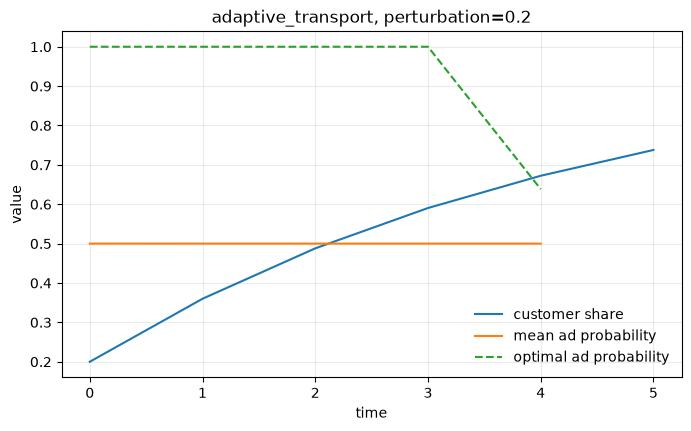

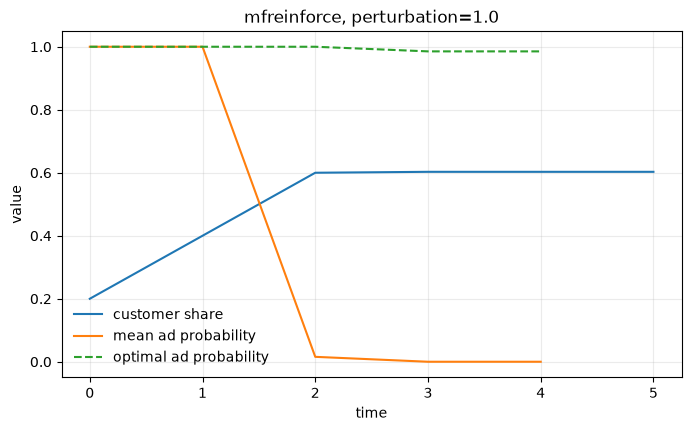

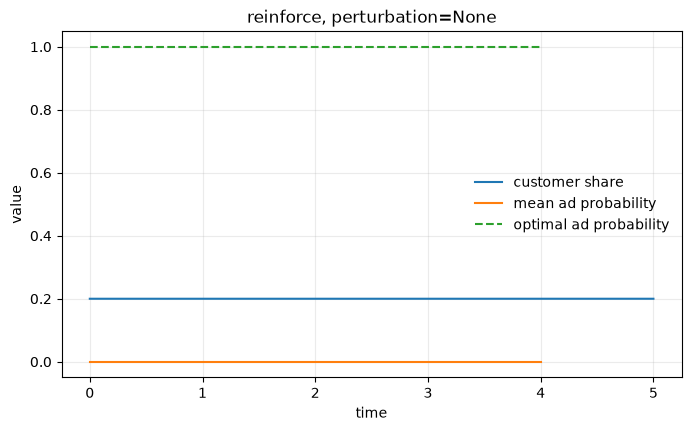

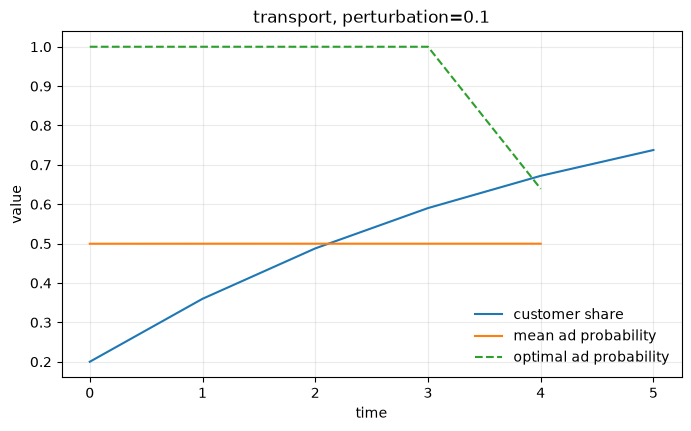

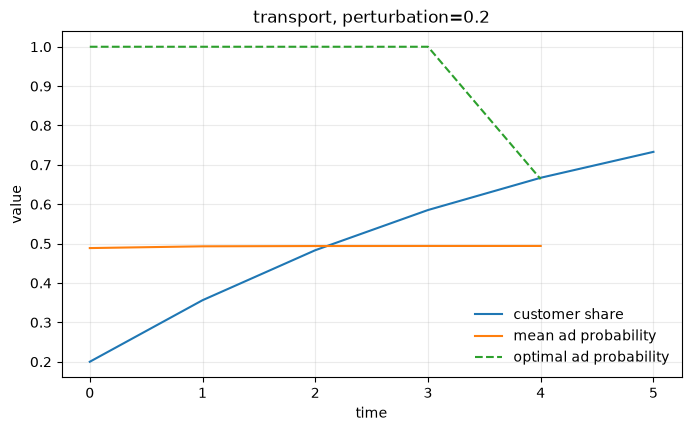

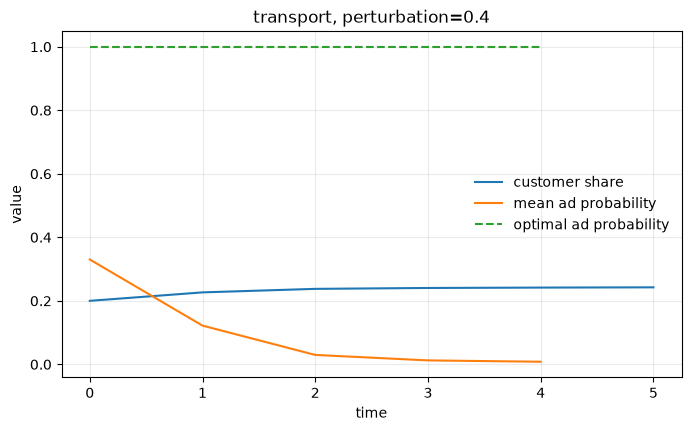

In [3]:
for run in best_runs_by_label(runs):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    plot_advertising_diagnostics(run, ax=ax)
    meta = run['metadata']
    ax.set_title(f"{meta['algorithm']}, perturbation={meta['perturbation']}")
    plt.show()

## State Distribution Flow

State-probability trajectories for not-customers and customers under the learned policies.

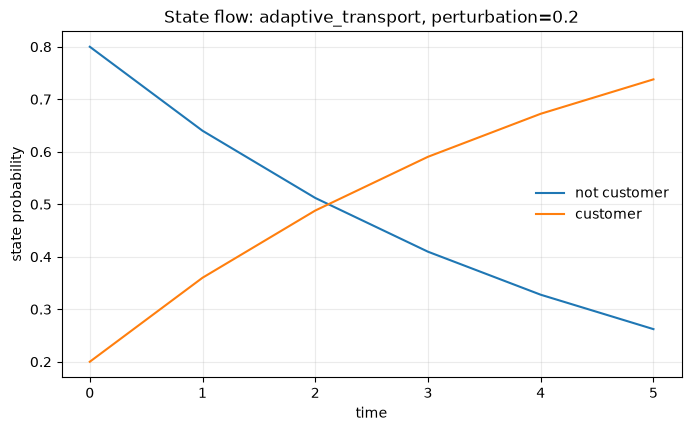

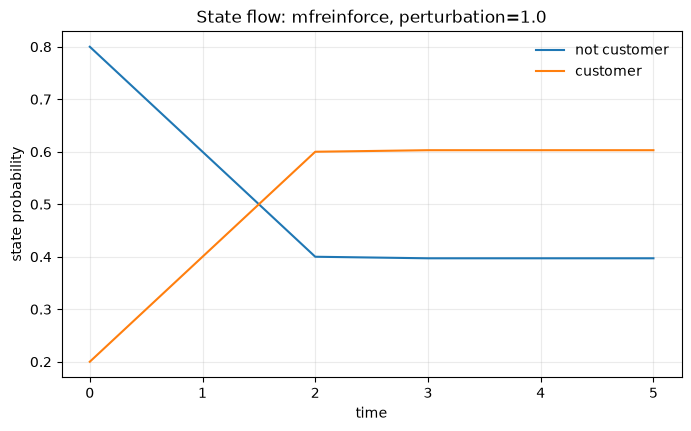

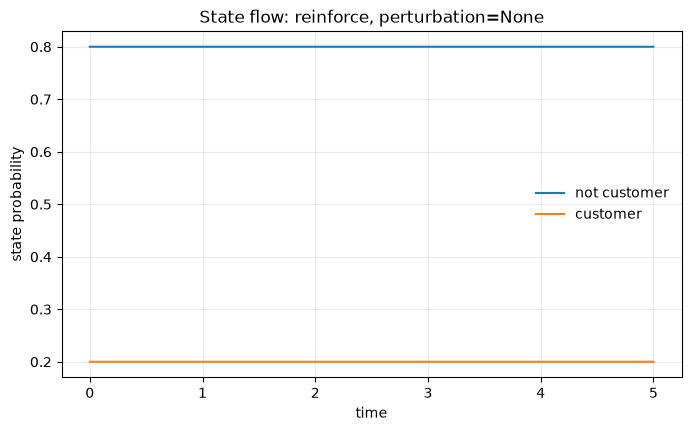

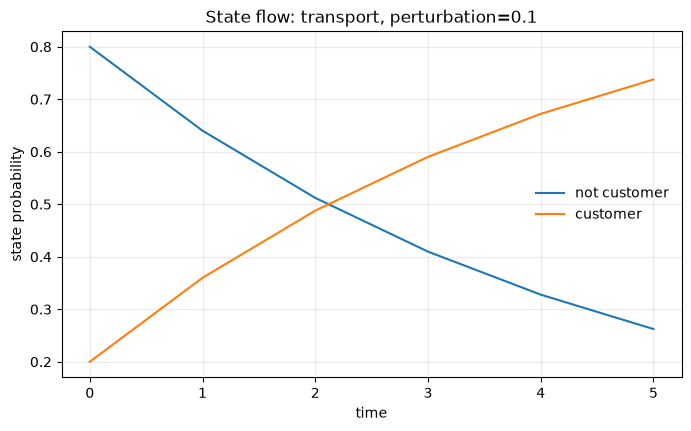

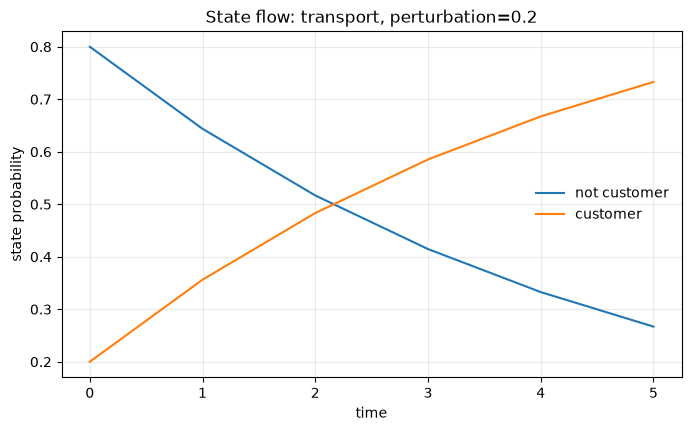

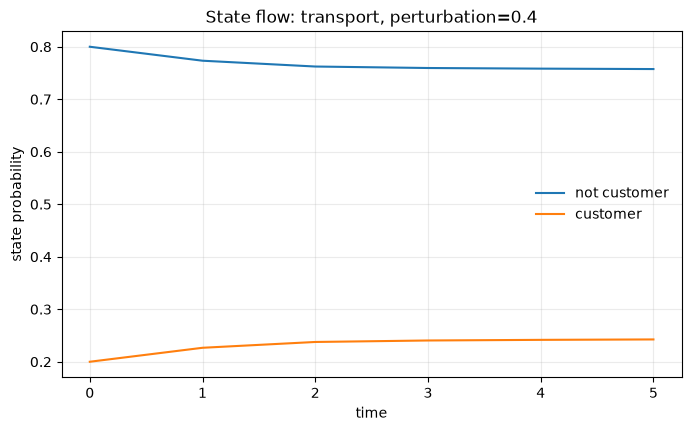

In [4]:
for run in best_runs_by_label(runs):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    plot_state_flow(run, ax=ax)
    meta = run['metadata']
    ax.set_title(f"State flow: {meta['algorithm']}, perturbation={meta['perturbation']}")
    plt.show()

## Transport Perturbation Bound

For simplex transport, the total-variation distance between the perturbed and unperturbed population laws is bounded by the selected `lambda`.

In [5]:
tv_bounds = discrete_transport_tv_bound_table(runs)
display(tv_bounds if not tv_bounds.empty else pd.DataFrame({'message': ['No transport runs found yet.']}))

,env,label,flow,horizon,seed,lambda,eta,max_tv_upper_bound,satisfies_lambda_bound
0,advertising,"Transport lambda=0.1, eta=0.85",exact,5,0,0.1,0.85,0.08,True
1,advertising,"Transport lambda=0.1, eta=0.85",exact,5,1,0.1,0.85,0.08,True
2,advertising,"Transport lambda=0.1, eta=0.85",exact,5,2,0.1,0.85,0.08,True
3,advertising,"Transport lambda=0.1, eta=0.85",exact,5,3,0.1,0.85,0.08,True
4,advertising,"Transport lambda=0.1, eta=0.85",exact,5,4,0.1,0.85,0.08,True
5,advertising,"Transport lambda=0.2, eta=0.85",exact,5,0,0.2,0.85,0.16,True
6,advertising,"Transport lambda=0.2, eta=0.85",exact,5,1,0.2,0.85,0.16,True
7,advertising,"Transport lambda=0.2, eta=0.85",exact,5,2,0.2,0.85,0.16,True
8,advertising,"Transport lambda=0.2, eta=0.85",exact,5,3,0.2,0.85,0.16,True
9,advertising,"Transport lambda=0.2, eta=0.85",exact,5,4,0.2,0.85,0.16,True


## Objective and Runtime Tables

Final validation reward, estimated simulator budget, and runtime summaries.

In [6]:
display(objective_table(runs))
display(runtime_table(runs))

,env,label,flow,horizon,eta,seed,validation_reward
0,advertising,"Adaptive transport lambda0=0.2, eta0=0.8",exact,5,0.349412,0,0.966985
1,advertising,"Adaptive transport lambda0=0.2, eta0=0.8",exact,5,0.369937,1,0.986309
2,advertising,"Adaptive transport lambda0=0.2, eta0=0.8",exact,5,0.349431,2,0.971821
3,advertising,"Adaptive transport lambda0=0.2, eta0=0.8",exact,5,0.338964,3,0.969625
4,advertising,"Adaptive transport lambda0=0.2, eta0=0.8",exact,5,0.399390,4,0.968749
5,advertising,MF-REINFORCE eps=1,exact,5,1.000000,0,0.998890
6,advertising,MF-REINFORCE eps=1,exact,5,1.000000,1,0.978368
7,advertising,MF-REINFORCE eps=1,exact,5,1.000000,2,0.998409
8,advertising,MF-REINFORCE eps=1,exact,5,1.000000,3,0.998976
9,advertising,MF-REINFORCE eps=1,exact,5,1.000000,4,0.998126


,env,algorithm,perturbation,eta,horizon,flow,setup_seconds_mean,setup_seconds_std,train_step_seconds_mean,train_step_seconds_std,validation_seconds_mean,validation_seconds_std,elapsed_seconds_mean,elapsed_seconds_std,seconds_per_step_mean,wall_seconds_per_step_mean,validation_seconds_per_call_mean,simulator_budget_mean,n_runs
0,advertising,adaptive_transport,0.2,NaN,5,exact,8.529004,0.378007,252.412155,2.358704,78.228159,0.658035,339.207313,2.827720,0.025241,0.033921,0.078228,1296.0,5
1,advertising,mfreinforce,1.0,1.00,5,exact,8.106305,0.493292,364.862494,1.450003,90.081616,0.446947,463.091832,2.193474,0.036486,0.046309,0.090082,1300.0,5
2,advertising,reinforce,NaN,NaN,5,exact,8.045109,0.535599,49.246890,0.371320,88.232809,0.643786,145.561609,1.387073,0.004925,0.014556,0.088233,1300.0,5
3,advertising,transport,0.1,0.85,5,exact,8.528370,1.471598,272.607408,1.316300,90.330302,0.506197,371.511838,2.063499,0.027261,0.037151,0.090330,1300.0,5
4,advertising,transport,0.2,0.85,5,exact,7.910378,1.295633,270.942661,0.772607,89.552931,0.610566,368.442235,2.286387,0.027094,0.036844,0.089553,1300.0,5
5,advertising,transport,0.4,0.85,5,exact,8.164380,1.058475,268.351740,1.585949,89.622581,0.933827,366.179167,2.104331,0.026835,0.036618,0.089623,1300.0,5
